[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open    Volume
Ticker          GOOGL      GOOGL      GOOGL      GOOGL     GOOGL
Date                                                            
2019-01-02  52.301720  52.604715  50.843769  50.938982  31868000
2019-01-03  50.853199  52.875982  50.699471  52.102873  41960000
2019-01-04  53.461636  53.557345  51.418025  51.700689  46022000
2019-01-07  53.355019  53.691237  52.696460  53.605447  47446000
2019-01-08  53.823650  54.219378  52.979624  53.854890  35414000


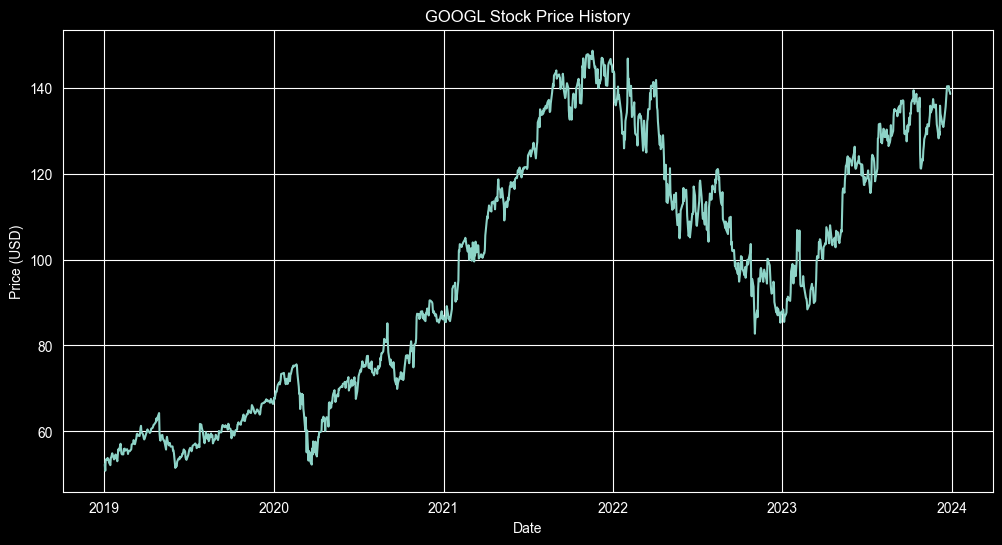

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf.

# Google ka pichle 5 saal ka data download karein
ticker = 'GOOGL'
df_stock = yf.download(ticker, start='2019-01-01', end='2024-01-01')

# Check karein data kaisa dikhta hai
print(df_stock.head())

# Sirf 'Close' price ko visualize karein (kyunki humne price predict karni hai)
plt.figure(figsize=(12,6))
plt.plot(df_stock['Close'])
plt.title(f'{ticker} Stock Price History')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()


[*********************100%***********************]  1 of 1 completed


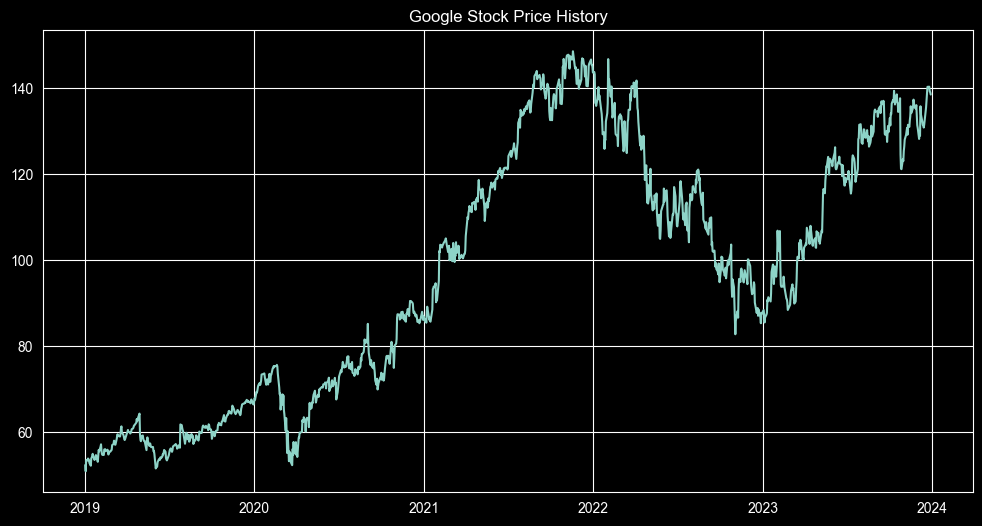

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# 1. Google (GOOGL) ka data download karein
df_stock = yf.download('GOOGL', start='2019-01-01', end='2024-01-01')

# 2. Graph check karein
plt.figure(figsize=(12,6))
plt.plot(df_stock['Close'])
plt.title('Google Stock Price History')
plt.show()


In [4]:
# 'Close' column ko sahi tarah se extract karein (Handling MultiIndex)
if isinstance(df_stock.columns, pd.MultiIndex):
    data = df_stock['Close'].values.reshape(-1, 1)
else:
    data = df_stock[['Close']].values.reshape(-1, 1)

# Data ko 0 aur 1 ke beech scale karein
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Training set size (80%)
training_data_len = int(np.ceil(len(scaled_data) * 0.8))
train_data = scaled_data[0:int(training_data_len), :]

# Sequences banayein (60 days lookback)
x_train, y_train = [], []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

# Arrays mein convert aur LSTM ke liye 3D Reshape
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(f"Data ready! X_train shape: {x_train.shape}")


Data ready! X_train shape: (947, 60, 1)


In [5]:
# Model design karein
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile aur Train (sirf 1 epoch testing ke liye)
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, batch_size=1, epochs=1)

print("Model Training Complete!")


C:\Users\f24ar\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


947/947 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0046
Model Training Complete!


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


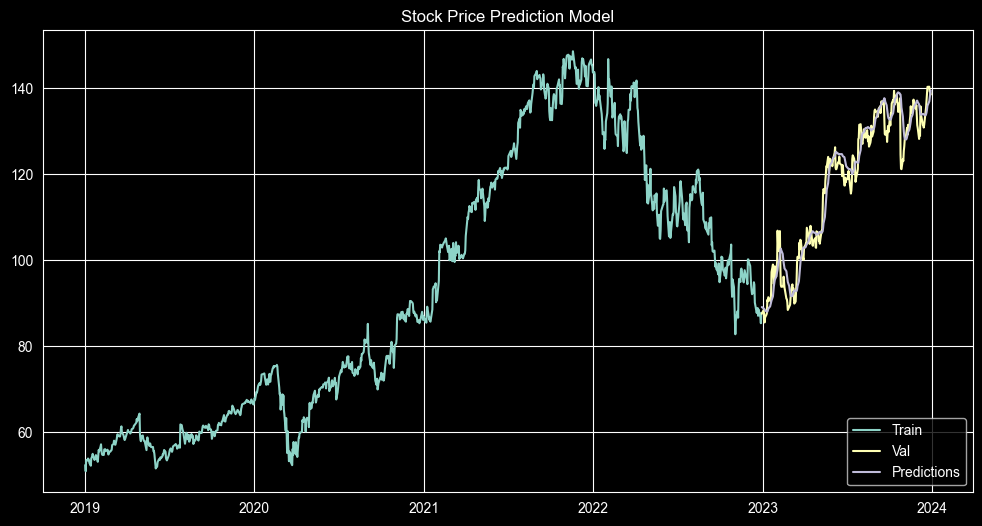

In [7]:
# Testing data tayyar karein
test_data = scaled_data[training_data_len - 60: , :]
x_test = []
y_test = data[training_data_len:, :]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Predictions karein
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions) # Back to dollar values

# Result Plot karein
train = df_stock[:training_data_len]
valid = df_stock[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(12,6))
plt.title('Stock Price Prediction Model')
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()
